In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## GPU Check

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Bạn chưa bật GPU. Vào Runtime > Change runtime type > GPU")

CUDA available: True
GPU: Tesla T4


## Install Required Packages

In [ ]:
!pip install -q "numpy<2"
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless tqdm matplotlib scikit-learn

## Fix Package Versions

In [ ]:
!pip uninstall -y numpy albumentations opencv-python opencv-python-headless

!pip install -q --no-cache-dir --force-reinstall "numpy==1.26.4"
!pip install -q --no-cache-dir "opencv-python-headless==4.10.0.84"
!pip install -q --no-cache-dir "albumentations==1.4.24"
!pip install -q --no-cache-dir "segmentation-models-pytorch==0.3.4"
!pip install -q --no-cache-dir tqdm matplotlib scikit-learn

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: albumentations 1.4.24
Uninstalling albumentations-1.4.24:
  Successfully uninstalled albumentations-1.4.24
Found existing installation: opencv-python-headless 4.10.0.84
Uninstalling opencv-python-headless-4.10.0.84:
  Successfully uninstalled opencv-python-headless-4.10.0.84
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.23 requires opencv-python-headless>=4.9.0.80, which is not installed.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x

## Import Libraries

In [ ]:
import os
import cv2
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Albumentations:", A.__version__)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


NumPy: 1.26.4
OpenCV: 4.10.0
Albumentations: 1.4.24
Torch: 2.10.0+cu128
CUDA: True


## Configuration

In [ ]:
import os
import json
import random
import numpy as np
import torch

# =========================
# Dataset path
# =========================
DATA_DIR = "/content/drive/MyDrive/processed"

TRAIN_IMG_DIR = f"{DATA_DIR}/train/images"
TRAIN_MASK_DIR = f"{DATA_DIR}/train/masks"

VAL_IMG_DIR = f"{DATA_DIR}/val/images"
VAL_MASK_DIR = f"{DATA_DIR}/val/masks"

TEST_IMG_DIR = f"{DATA_DIR}/test/images"
TEST_MASK_DIR = f"{DATA_DIR}/test/masks"

# =========================
# Training config
# =========================
IMAGE_SIZE = 512
BATCH_SIZE = 4
EPOCHS = 50
LR = 1e-4

# Early stopping
PATIENCE = 8
MIN_DELTA = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Save folder
SAVE_DIR = "/content/drive/MyDrive/tomato_segnet_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = f"{SAVE_DIR}/best_segnet_model.pth"
LAST_MODEL_PATH = f"{SAVE_DIR}/last_segnet_model.pth"
HISTORY_PATH = f"{SAVE_DIR}/segnet_training_history.json"

# Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Dataset root:", DATA_DIR)
print("Save dir:", SAVE_DIR)

Device: cuda
Dataset root: /content/drive/MyDrive/processed
Save dir: /content/drive/MyDrive/tomato_segnet_checkpoints


## Check Dataset

In [ ]:
from pathlib import Path

def count_image_files(folder):
    exts = [".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP"]
    folder = Path(folder)

    if not folder.exists():
        print("Không tồn tại:", folder)
        return 0

    return len([f for f in folder.glob("*") if f.suffix in exts])

print("Train images:", count_image_files(TRAIN_IMG_DIR))
print("Train masks :", count_image_files(TRAIN_MASK_DIR))

print("Val images  :", count_image_files(VAL_IMG_DIR))
print("Val masks   :", count_image_files(VAL_MASK_DIR))

print("Test images :", count_image_files(TEST_IMG_DIR))
print("Test masks  :", count_image_files(TEST_MASK_DIR))

Train images: 5634
Train masks : 5619
Val images  : 1207
Val masks   : 1203
Test images : 1213
Test masks  : 1210


## Dataset Class

In [ ]:
class TomatoSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.transform = transform

        image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP"]

        image_paths = [
            p for p in self.images_dir.glob("*")
            if p.suffix in image_exts
        ]

        mask_paths = [
            p for p in self.masks_dir.glob("*")
            if p.suffix in image_exts
        ]

        # Map mask theo tên file không tính đuôi
        # Ví dụ: abc.jpg và abc.png vẫn được xem là cùng cặp
        mask_map = {p.stem: p for p in mask_paths}

        self.pairs = []
        missing_masks = 0

        for img_path in image_paths:
            if img_path.stem in mask_map:
                self.pairs.append((img_path, mask_map[img_path.stem]))
            else:
                missing_masks += 1

        self.pairs = sorted(self.pairs, key=lambda x: x[0].name)

        print("Images found:", len(image_paths))
        print("Masks found :", len(mask_paths))
        print("Valid pairs :", len(self.pairs))
        print("Missing masks skipped:", missing_masks)

        if len(self.pairs) == 0:
            raise RuntimeError("Không tìm thấy cặp image-mask hợp lệ. Kiểm tra lại đường dẫn dataset.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = cv2.imread(str(img_path))
        if image is None:
            raise RuntimeError(f"Không đọc được ảnh: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise RuntimeError(f"Không đọc được mask: {mask_path}")

        # Đưa mask về binary: 0 hoặc 1
        mask = (mask > 127).astype("float32")

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # Sau ToTensorV2, image: [3, H, W], mask: [H, W]
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        mask = mask.float()

        return image, mask

## Data Augmentation

In [ ]:
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.3
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

## Create DataLoaders

In [ ]:
train_dataset = TomatoSegmentationDataset(
    images_dir=TRAIN_IMG_DIR,
    masks_dir=TRAIN_MASK_DIR,
    transform=train_transform
)

val_dataset = TomatoSegmentationDataset(
    images_dir=VAL_IMG_DIR,
    masks_dir=VAL_MASK_DIR,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Images found: 5634
Masks found : 5619
Valid pairs : 5618
Missing masks skipped: 16
Images found: 1207
Masks found : 1203
Valid pairs : 1203
Missing masks skipped: 4
Train dataset: 5618
Val dataset  : 1203
Train batches: 1405
Val batches  : 301


## Visualize Sample

Image batch: torch.Size([4, 3, 512, 512])
Mask batch : torch.Size([4, 1, 512, 512])


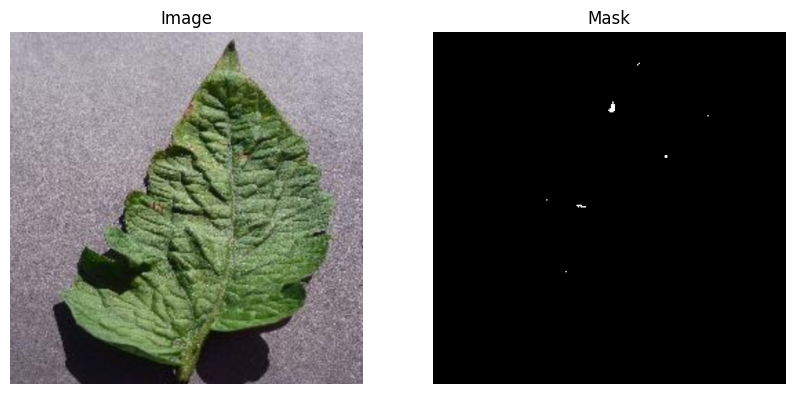

In [ ]:
images, masks = next(iter(train_loader))

print("Image batch:", images.shape)
print("Mask batch :", masks.shape)

img = images[0].permute(1, 2, 0).cpu().numpy()
mask = masks[0][0].cpu().numpy()

# Unnormalize để hiển thị ảnh đúng màu
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img = std * img + mean
img = np.clip(img, 0, 1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

## Define SegNet Model

In [ ]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SegNet, self).__init__()

        # Encoder
        self.enc_conv0 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.pool0 = nn.MaxPool2d(2, 2, return_indices=True)

        self.enc_conv1 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2, 2, return_indices=True)

        self.enc_conv2 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2, 2, return_indices=True)

        # Decoder
        self.unpool2 = nn.MaxUnpool2d(2, 2)
        self.dec_conv2 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.unpool1 = nn.MaxUnpool2d(2, 2)
        self.dec_conv1 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.unpool0 = nn.MaxUnpool2d(2, 2)
        self.dec_conv0 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, out_channels, 3, padding=1),
        )

    def forward(self, x):
        # Encoder
        x, idx0 = self.pool0(self.enc_conv0(x))
        x, idx1 = self.pool1(self.enc_conv1(x))
        x, idx2 = self.pool2(self.enc_conv2(x))

        # Decoder
        x = self.dec_conv2(self.unpool2(x, idx2))
        x = self.dec_conv1(self.unpool1(x, idx1))
        x = self.dec_conv0(self.unpool0(x, idx0))
        return x

model = SegNet(in_channels=3, out_channels=1).to(DEVICE)

print("Model: SegNet")
print("Device:", DEVICE)

Model: SegNet
Device: cuda


## Loss and Metrics

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

def loss_fn(logits, masks):
    bce = bce_loss(logits, masks)
    dice = dice_loss(logits, masks)
    return bce + dice


def calculate_metrics(logits, masks, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    masks = masks.float()

    intersection = (preds * masks).sum(dim=(1, 2, 3))
    pred_sum = preds.sum(dim=(1, 2, 3))
    mask_sum = masks.sum(dim=(1, 2, 3))
    union = pred_sum + mask_sum - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred_sum + mask_sum + eps)

    tp = intersection
    fp = pred_sum - intersection
    fn = mask_sum - intersection

    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    accuracy = (preds == masks).float().mean(dim=(1, 2, 3))

    return {
        "iou": iou.mean().item(),
        "dice": dice.mean().item(),
        "accuracy": accuracy.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

print("Loss: BCEWithLogitsLoss + DiceLoss")
print("Optimizer: AdamW")
print("LR:", LR)

Loss: BCEWithLogitsLoss + DiceLoss
Optimizer: AdamW
LR: 0.0001


/tmp/ipykernel_2204/354942499.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


## Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4, mode="max"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode

        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def is_improvement(self, current_score):
        if self.best_score is None:
            return True

        if self.mode == "max":
            return current_score > self.best_score + self.min_delta
        else:
            return current_score < self.best_score - self.min_delta

    def step(self, current_score):
        if self.is_improvement(current_score):
            self.best_score = current_score
            self.counter = 0
            return True
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.should_stop = True

            return False


early_stopping = EarlyStopping(
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    mode="max"
)

print("Early stopping patience:", PATIENCE)
print("Early stopping min_delta:", MIN_DELTA)

Early stopping patience: 8
Early stopping min_delta: 0.0001


## Training Functions

In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_acc = 0.0
    total_precision = 0.0
    total_recall = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, masks in progress_bar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(images)
            loss = loss_fn(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        metrics = calculate_metrics(logits.detach(), masks)

        total_loss += loss.item()
        total_iou += metrics["iou"]
        total_dice += metrics["dice"]
        total_acc += metrics["accuracy"]
        total_precision += metrics["precision"]
        total_recall += metrics["recall"]

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "iou": f"{metrics['iou']:.4f}",
            "dice": f"{metrics['dice']:.4f}"
        })

    n = len(loader)

    return {
        "loss": total_loss / n,
        "iou": total_iou / n,
        "dice": total_dice / n,
        "accuracy": total_acc / n,
        "precision": total_precision / n,
        "recall": total_recall / n
    }

## Validation Function

In [ ]:
@torch.no_grad()
def validate_one_epoch(model, loader):
    model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_acc = 0.0
    total_precision = 0.0
    total_recall = 0.0

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    for images, masks in progress_bar:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(images)
            loss = loss_fn(logits, masks)

        metrics = calculate_metrics(logits, masks)

        total_loss += loss.item()
        total_iou += metrics["iou"]
        total_dice += metrics["dice"]
        total_acc += metrics["accuracy"]
        total_precision += metrics["precision"]
        total_recall += metrics["recall"]

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "iou": f"{metrics['iou']:.4f}",
            "dice": f"{metrics['dice']:.4f}"
        })

    n = len(loader)

    return {
        "loss": total_loss / n,
        "iou": total_iou / n,
        "dice": total_dice / n,
        "accuracy": total_acc / n,
        "precision": total_precision / n,
        "recall": total_recall / n
    }

## Training Loop

In [ ]:
best_iou = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
    "train_dice": [],
    "val_dice": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "lr": []
}

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    print(f"\nEpoch [{epoch}/{EPOCHS}]")
    print("-" * 60)

    train_metrics = train_one_epoch(model, train_loader, optimizer)
    val_metrics = validate_one_epoch(model, val_loader)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_metrics["iou"])

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])

    history["train_iou"].append(train_metrics["iou"])
    history["val_iou"].append(val_metrics["iou"])

    history["train_dice"].append(train_metrics["dice"])
    history["val_dice"].append(val_metrics["dice"])

    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])

    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])

    history["lr"].append(current_lr)

    elapsed = time.time() - start_time

    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"IoU: {train_metrics['iou']:.4f} | "
        f"Dice: {train_metrics['dice']:.4f} | "
        f"Acc: {train_metrics['accuracy']:.4f}"
    )

    print(
        f"Val   Loss: {val_metrics['loss']:.4f} | "
        f"IoU: {val_metrics['iou']:.4f} | "
        f"Dice: {val_metrics['dice']:.4f} | "
        f"Acc: {val_metrics['accuracy']:.4f}"
    )

    print(
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f}"
    )

    print(f"LR: {current_lr:.8f}")
    print(f"Time: {elapsed:.2f}s")

    # Lưu last checkpoint
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_iou": best_iou,
        "history": history,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "lr": LR
    }, LAST_MODEL_PATH)

    # Early stopping kiểm tra theo Val IoU
    improved = early_stopping.step(val_metrics["iou"])

    if improved:
        best_iou = val_metrics["iou"]

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_iou": best_iou,
            "history": history,
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "lr": LR
        }, BEST_MODEL_PATH)

        print(f"Best model saved: {BEST_MODEL_PATH}")
        print(f"Best Val IoU: {best_iou:.4f}")
    else:
        print(
            f"No improvement. Early stopping counter: "
            f"{early_stopping.counter}/{early_stopping.patience}"
        )

    # Lưu history ra JSON sau mỗi epoch
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=4)

    if early_stopping.should_stop:
        print("\nEarly stopping activated.")
        print(f"Stopped at epoch {epoch}.")
        print(f"Best Val IoU: {best_iou:.4f}")
        break

print("\nTraining finished.")
print("Best Val IoU:", best_iou)
print("Best model path:", BEST_MODEL_PATH)
print("Last model path:", LAST_MODEL_PATH)
print("History path:", HISTORY_PATH)


Epoch [1/50]
------------------------------------------------------------


Training:   0%|          | 0/1405 [00:00<?, ?it/s]

/tmp/ipykernel_2204/328230529.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


Validation:   0%|          | 0/301 [00:00<?, ?it/s]

/tmp/ipykernel_2204/3887903170.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


...

Validation:   0%|          | 0/301 [00:00<?, ?it/s]

Train Loss: 0.4480 | IoU: 0.3447 | Dice: 0.4226 | Acc: 0.9895
Val   Loss: 0.5185 | IoU: 0.3796 | Dice: 0.4583 | Acc: 0.9912
Val Precision: 0.7684 | Val Recall: 0.4951
LR: 0.00000625
Time: 385.13s
No improvement. Early stopping counter: 7/8

Epoch [40/50]
------------------------------------------------------------


Training:   0%|          | 0/1405 [00:00<?, ?it/s]

Validation:   0%|          | 0/301 [00:00<?, ?it/s]

Train Loss: 0.4512 | IoU: 0.3426 | Dice: 0.4191 | Acc: 0.9894
Val   Loss: 0.5479 | IoU: 0.3596 | Dice: 0.4343 | Acc: 0.9912
Val Precision: 0.8275 | Val Recall: 0.4293
LR: 0.00000625
Time: 386.06s
No improvement. Early stopping counter: 8/8

Early stopping activated.
Stopped at epoch 40.
Best Val IoU: 0.3852

Training finished.
Best Val IoU: 0.3851694819546376
Best model path: /content/drive/MyDrive/tomato_segnet_checkpoints/best_segnet_model.pth
Last model path: /content/drive/MyDrive/tomato_segnet_checkpoints/last_segnet_model.pth
History path: /content/drive/MyDrive/tomato_segnet_checkpoints/segnet_training_history.json


## Plot Training History

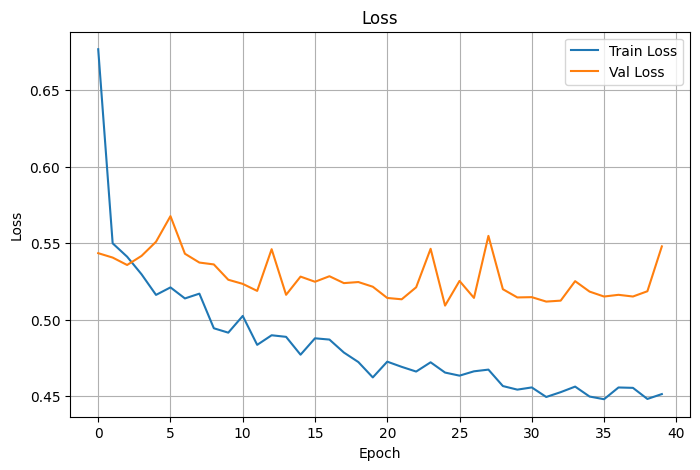

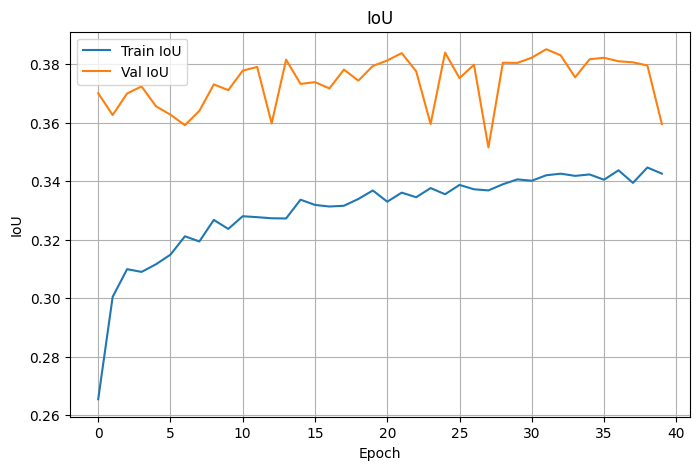

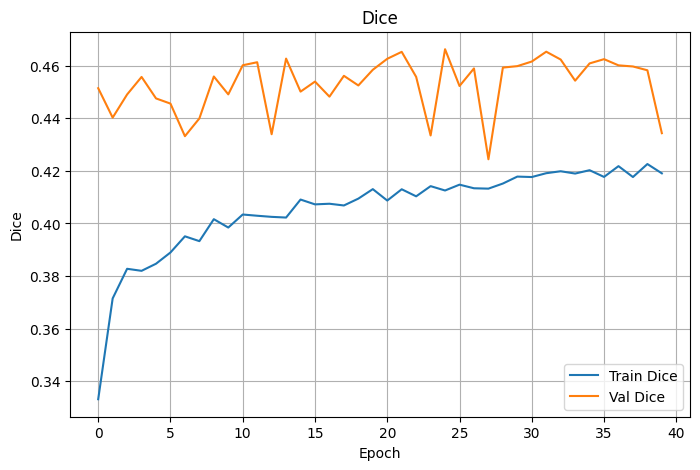

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_iou"], label="Train IoU")
plt.plot(history["val_iou"], label="Val IoU")
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_dice"], label="Train Dice")
plt.plot(history["val_dice"], label="Val Dice")
plt.title("Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid(True)
plt.show()

## Load Best Model

In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best model from:", BEST_MODEL_PATH)
print("Best IoU:", checkpoint["best_iou"])
print("Best epoch:", checkpoint["epoch"])

Loaded best model from: /content/drive/MyDrive/tomato_segnet_checkpoints/best_segnet_model.pth
Best IoU: 0.3851694819546376
Best epoch: 32


## Show Predictions

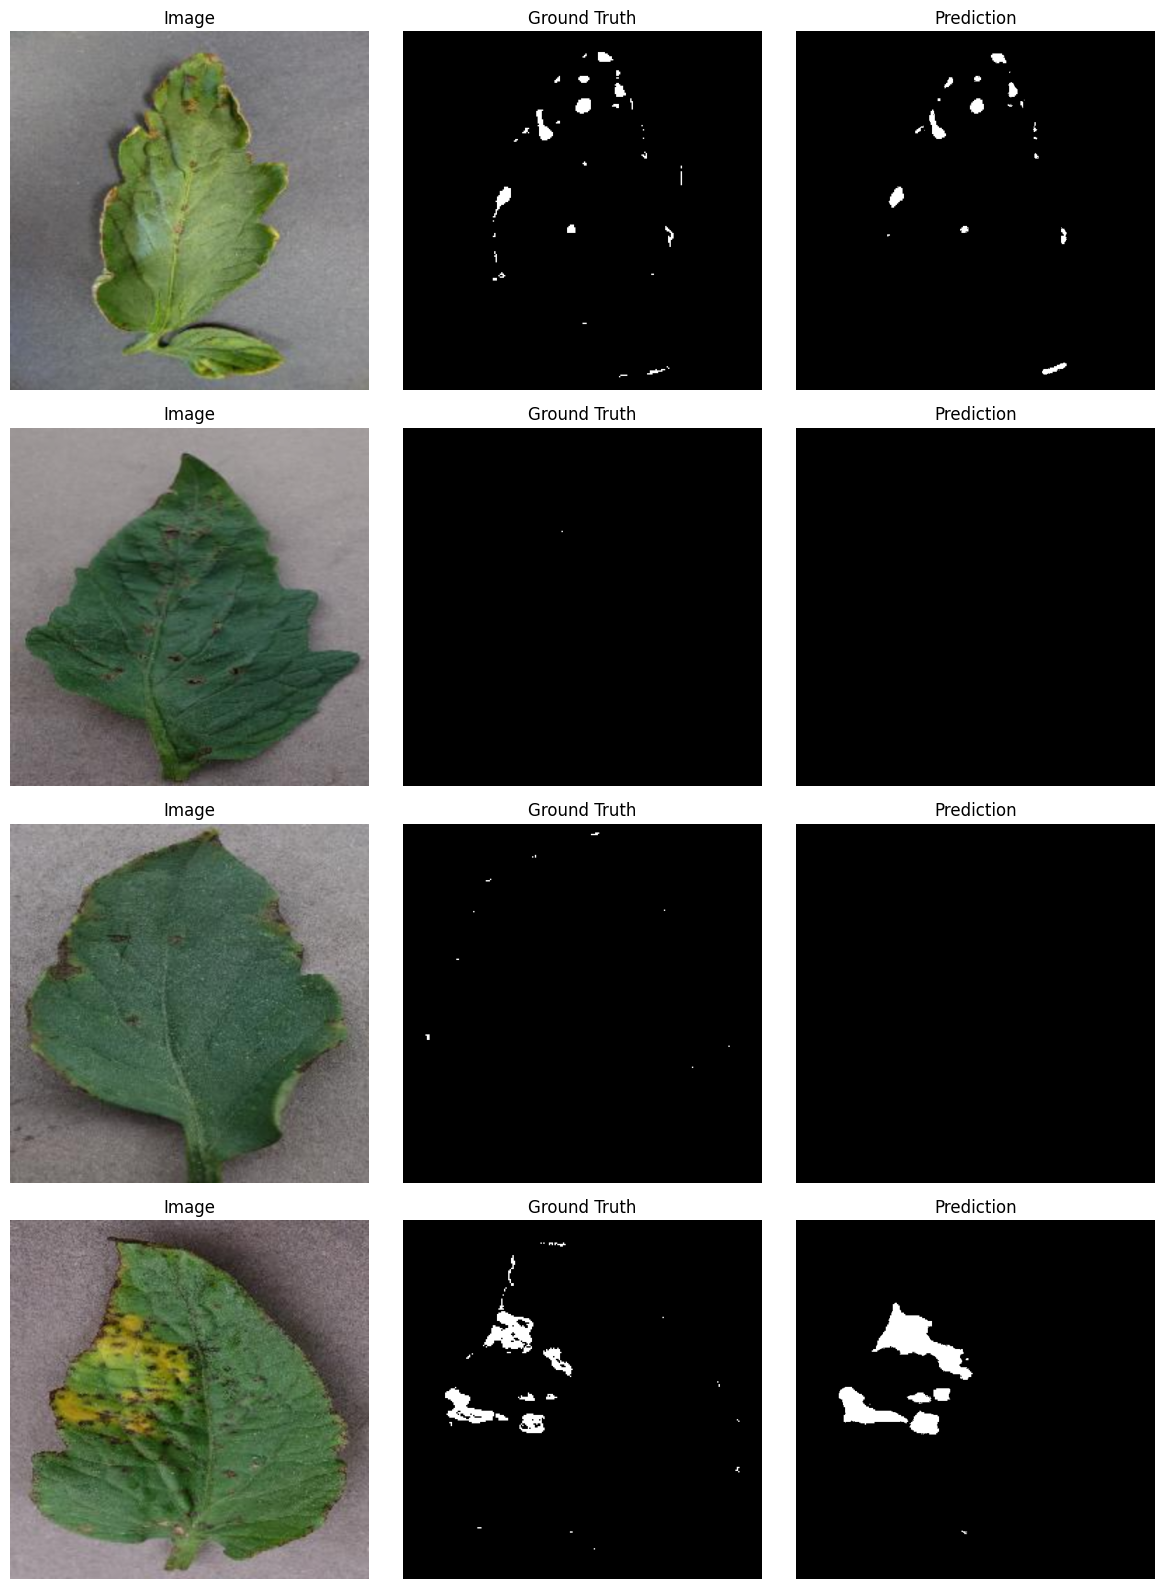

In [ ]:
@torch.no_grad()
def show_predictions(model, loader, num_samples=4, threshold=0.5):
    model.eval()

    images, masks = next(iter(loader))

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    n = min(num_samples, images.size(0))

    plt.figure(figsize=(12, 4 * n))

    for i in range(n):
        img = images[i].permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)

        gt_mask = masks[i][0].numpy()
        pred_mask = preds[i][0].numpy()

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(img)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(gt_mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(model, val_loader, num_samples=4, threshold=0.5)

## Test Evaluation

In [ ]:
test_dataset = TomatoSegmentationDataset(
    images_dir=TEST_IMG_DIR,
    masks_dir=TEST_MASK_DIR,
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_metrics = validate_one_epoch(model, test_loader)

print("Test results")
print("-" * 40)
print("Loss     :", round(test_metrics["loss"], 4))
print("IoU      :", round(test_metrics["iou"], 4))
print("Dice     :", round(test_metrics["dice"], 4))
print("Accuracy :", round(test_metrics["accuracy"], 4))
print("Precision:", round(test_metrics["precision"], 4))
print("Recall   :", round(test_metrics["recall"], 4))

Images found: 1213
Masks found : 1210
Valid pairs : 1210
Missing masks skipped: 3


Validation:   0%|          | 0/303 [00:00<?, ?it/s]

/tmp/ipykernel_2204/3887903170.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


Test results
----------------------------------------
Loss     : 0.5118
IoU      : 0.3717
Dice     : 0.4531
Accuracy : 0.9901
Precision: 0.7575
Recall   : 0.487


## Save Weights Only

In [ ]:
WEIGHTS_ONLY_PATH = f"{SAVE_DIR}/segnet_weights_only.pth"

torch.save(model.state_dict(), WEIGHTS_ONLY_PATH)

print("Saved weights only to:")
print(WEIGHTS_ONLY_PATH)

Saved weights only to:
/content/drive/MyDrive/tomato_segnet_checkpoints/segnet_weights_only.pth
